### Data Cleaning — 20 Questions


In [1]:
# 1. Column Names
#Display all column names. Identify columns having leading/trailing spaces and
#rename all columns into a consistent snake_case format.

import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("C:\\Users\\DELL\\Downloads\\matplotlib_messy_sales_2000 - matplotlib_messy_sales_2000.csv")

In [2]:
df.columns

Index(['Customer ID', 'Order Date', 'City', 'Product Category',
       'Customer Segment', 'Gender', 'Sales Channel', 'Age', 'Units Sold',
       'Unit Price', 'Discount %', 'Customer Rating', 'Is Active', 'Returned',
       'Payment Method', 'Gross Sales', 'Discount Amount', 'Revenue', 'Cost',
       'Profit'],
      dtype='object')

In [3]:
df.columns = (df.columns.str.strip().str.lower().str.replace(" ","_"))
df.columns

Index(['customer_id', 'order_date', 'city', 'product_category',
       'customer_segment', 'gender', 'sales_channel', 'age', 'units_sold',
       'unit_price', 'discount_%', 'customer_rating', 'is_active', 'returned',
       'payment_method', 'gross_sales', 'discount_amount', 'revenue', 'cost',
       'profit'],
      dtype='object')

In [4]:
#2. Duplicate Records
#Find the number of duplicate rows. Remove the duplicate records and verify that no
#duplicates remain.

print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [5]:

df = pd.read_csv("C:\\Users\\DELL\\Downloads\\matplotlib_messy_sales_2000 - matplotlib_messy_sales_2000.csv")

In [6]:
df.duplicated().sum()

np.int64(20)

In [7]:
df=df.drop_duplicates()

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# 3. Missing Values
#Display the missing-value count and missing-value percentage for every column.

missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum()/len(df))*100
missing_sumary = pd.DataFrame({"missing_count":missing_count,"missing_percentage":missing_percentage})
missing_sumary

,missing_count,missing_percentage
Customer ID,0,0.00
Order Date,4,0.20
City,25,1.25
Product Category,24,1.20
Customer Segment,0,0.00
Gender,0,0.00
Sales Channel,0,0.00
Age,27,1.35
Units Sold,4,0.20
Unit Price,24,1.20


In [10]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['customer_id', 'order_date', 'city', 'product_category', 'customer_segment', 'gender', 'sales_channel', 'age', 'units_sold', 'unit_price', 'discount_%', 'customer_rating', 'is_active', 'returned', 'payment_method', 'gross_sales', 'discount_amount', 'revenue', 'cost', 'profit']


In [11]:
#4. Missing Categorical Values
#Handle missing values in city, product_category, and payment_method using an
#appropriate strategy.
# Fill missing categorical values with mode

df["city"] = df["city"].fillna(df["city"].mode()[0])

df["product_category"] = df["product_category"].fillna(
    df["product_category"].mode()[0]
)

df["payment_method"] = df["payment_method"].fillna(
    df["payment_method"].mode()[0]
)

# Verify missing values
print(df[["city", "product_category", "payment_method"]].isnull().sum())

city                0
product_category    0
payment_method      0
dtype: int64


In [12]:
#5. Missing Numerical Values
#Handle missing values in age, unit_price, discount_pct, customer_rating, and
#revenue. Explain why you selected mean, median, or another method.


# Age - convert to numeric and fill missing values with median
df["age"] = pd.to_numeric(
    df["age"].astype(str).str.replace("years", "").str.strip(),
    errors="coerce"
)
df["age"] = df["age"].fillna(df["age"].median())


# Unit Price - convert to numeric and fill missing values with median
df["unit_price"] = pd.to_numeric(
    df["unit_price"].astype(str).str.replace(",", "").str.strip(),
    errors="coerce"
)
df["unit_price"] = df["unit_price"].fillna(df["unit_price"].median())


# Discount Percentage
df["discount_%"] = pd.to_numeric(
    df["discount_%"],
    errors="coerce"
)
df["discount_%"] = df["discount_%"].fillna(
    df["discount_%"].median()
)


# Customer Rating
df["customer_rating"] = pd.to_numeric(
    df["customer_rating"],
    errors="coerce"
)
df["customer_rating"] = df["customer_rating"].fillna(
    df["customer_rating"].median()
)


# Revenue
df["revenue"] = pd.to_numeric(
    df["revenue"],
    errors="coerce"
)
df["revenue"] = df["revenue"].fillna(
    df["revenue"].median()
)


# Verify missing values
print(df[[
    "age",
    "unit_price",
    "discount_%",
    "customer_rating",
    "revenue"
]].isnull().sum())

age                0
unit_price         0
discount_%         0
customer_rating    0
revenue            0
dtype: int64


In [13]:
# 6. Date Cleaning
#Convert order_date into a proper datetime format. Identify invalid date values and
#handle them appropriately.

# Convert order_date to datetime
df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce"
)

# Identify invalid/missing dates
print("Invalid date values:", df["order_date"].isna().sum())

# Display rows with invalid dates
print(df[df["order_date"].isna()])

# Handle invalid dates by removing those rows
df = df.dropna(subset=["order_date"])

# Verify
print("Invalid dates remaining:", df["order_date"].isna().sum())

Invalid date values: 25
     customer_id order_date       city product_category customer_segment  \
34     CUST00092        NaT       Pune   Home & Kitchen           Budget   
52     CUST00807        NaT  Bengaluru   Home & Kitchen           Budget   
58     CUST01070        NaT     Mumbai   Home & Kitchen          Regular   
187    CUST00750        NaT  Hyderabad           Beauty          Premium   
238    CUST01938        NaT       Pune         Clothing           Budget   
317    CUST00595        NaT      Delhi           Beauty           Budget   
329    CUST00905        NaT      Delhi      Electronics          Premium   
333    CUST01839        NaT     Mumbai   Home & Kitchen          Regular   
347    CUST00751        NaT  Hyderabad           Sports          Premium   
394    CUST01627        NaT  Bengaluru      Electronics          Regular   
582    CUST00822        NaT      Delhi         Clothing          Premium   
670    CUST01154        NaT       Pune         Clothing         

In [21]:
# 7. Age Cleaning
#The age column contains values such as 25 years, 30 yrs, 45Y, and N/A. Extract the
#numerical age and convert the column into a numeric datatype.

df["age"] = df["age"].astype(str).str.extract(r"(\d+\.?\d*)")[0]
df["age"] = pd.to_numeric(df["age"], errors="coerce")
print(df["age"].head(10))

0    36.0
1    38.0
2    65.0
3    34.0
4    41.0
5    49.0
6    29.0
7    46.0
8    61.0
9    25.0
Name: age, dtype: float64


In [24]:
df["age"].dtype

dtype('float64')

### Matplotlib — 15 Visualization Questions

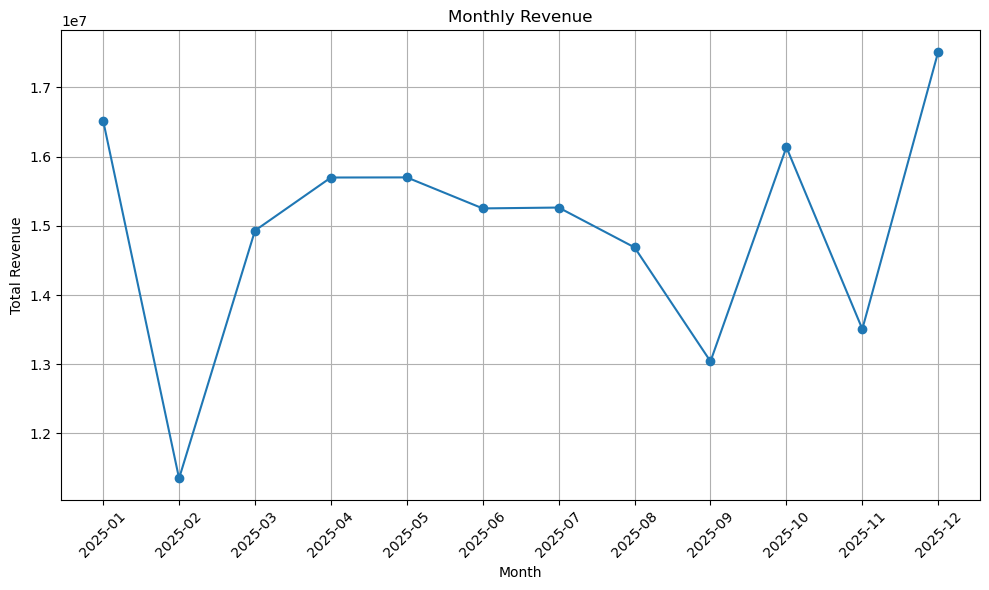

In [16]:
# 1. Monthly Revenue Line Chart
#Using order_date and revenue:
#• Convert order_date to datetime.
#• Calculate total revenue for each month.
#• Create a line chart.
#o Title
#o X-axis label
#o Y-axis label
#o Grid
#Commands/concepts: plt.plot(), plt.title(), plt.xlabel(), plt.ylabel(), plt.grid()

import pandas as pd
import matplotlib.pyplot as plt

# Convert order_date to datetime
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

# Calculate total revenue for each month
monthly_revenue = df.groupby(
    df["order_date"].dt.to_period("M")
)["revenue"].sum()

# Convert period to string for plotting
monthly_revenue.index = monthly_revenue.index.astype(str)

# Create line chart
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

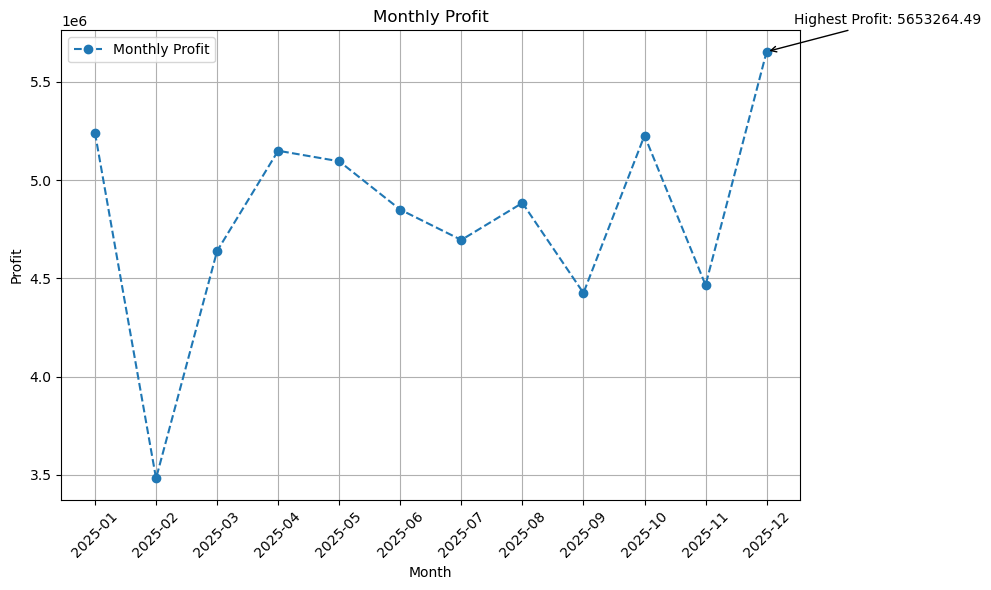

In [15]:
# 2. Monthly Profit Line Chart
#Create a line chart showing monthly Profit.
#Requirements:
#• Use a different line style.
#• Add markers.
#• Add a legend.
#• Display the value of the highest-profit month using annotate().
#Commands/concepts: plt.plot(), plt.legend(), plt.annotate()

import pandas as pd
import matplotlib.pyplot as plt

# Convert order_date to datetime
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

# Make sure profit is numeric
df["profit"] = pd.to_numeric(df["profit"], errors="coerce")

# Calculate monthly profit
monthly_profit = df.groupby(
    df["order_date"].dt.to_period("M")
)["profit"].sum()

# Convert index to string
monthly_profit.index = monthly_profit.index.astype(str)

# Create line chart
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_profit.index,
    monthly_profit.values,
    linestyle="--",
    marker="o",
    label="Monthly Profit"
)

plt.title("Monthly Profit")
plt.xlabel("Month")
plt.ylabel("Profit")

# Add legend
plt.legend()

# Find highest-profit month
highest_month = monthly_profit.idxmax()
highest_profit = monthly_profit.max()

# Annotate highest profit
plt.annotate(
    f"Highest Profit: {highest_profit:.2f}",
    xy=(highest_month, highest_profit),
    xytext=(20, 20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()